**This notebook demonstrates:**

- Loading SOLPS output into a `dataset` object
- Loading a SOLPS quantity (particle flux) for a given species (deuterium ions) in a given projection (radial)
- Plotting this quantity on the 2D B2.5 mesh using [solps-viewer](https://repo.tok.ipp.cas.cz/dms/solps-viewer)
- Plotting the B2.5 mesh
- Loading data from your own SOLPS-ITER simulation

**TODO**: Link to a tutorial explaining how to access individual cell values.


## Initialization

In [1]:
# Turn on interactive plots
%matplotlib notebook

# Provide path to an example simulation - COMPASS #16908 with carbon impurities
sim_path = "/compass/Shared/Common/IT/DMS/solps-postproc/data/solps/compass_carbon_16908/run"

## Full script

<IPython.core.display.Javascript object>


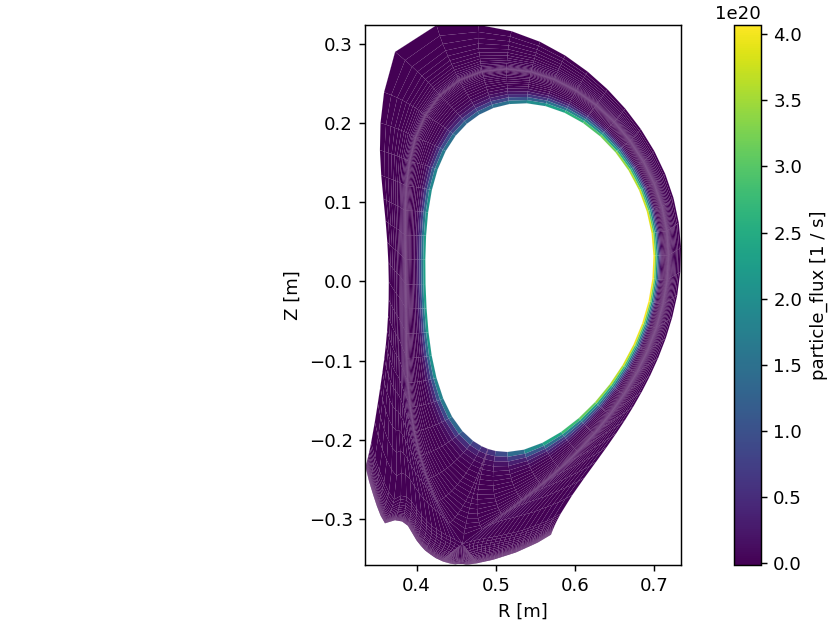

<Axes: xlabel='R [m]', ylabel='Z [m]'>

In [2]:
from solps_postproc import data  # loading annotated SOLPS data
from solps_viewer import SOLPSMesh  # plotting SOLPS data on a mesh

# Load data from the SOLPS simulation
dataset = data.fields.load(sim_path)

# Build a mesh object
mesh = SOLPSMesh.from_ds(dataset)

# Select the radial deuterium ion particle flux
Gammai_r = dataset.particle_flux.sel(species='D_1+', e_pol='radial')

# Plot the particle flux in 2D
mesh.plot(Gammai_r)

## Step by step

### Imports

First, we import the modules used for loading and plotting SOLPS data. Both of these modules are pre-loaded in the SOLPS [Python 3.9] environment.

In [3]:
from solps_postproc import data  # loading annotated SOLPS data
from solps_viewer import SOLPSMesh  # plotting SOLPS data on a mesh

### Load SOLPS output into the `dataset` object

We load the SOLPS output data from a given run path `sim_path` into an annotated object `dataset`. The `sim_path` in this tutorial points to an example simulation, shipped with `solps-postproc`. You can modify `sim_path` so it points to your own `run` folder. If your simulation is not stored on Soroban, you will need to copy a few output files to Soroban and define `sim_path` to point on the folder containing the copies. More on this below.

In [4]:
# Load SOLPS data into the dataset object
dataset = data.fields.load(sim_path)

# Inspect the dataset object
dataset

<xarray.Dataset>
Dimensions:                     (iy: 38, ix: 86, vertex_id: 3392,
                                 polygon_vertex: 4, species: 11, e_pol: 3,
                                 e_cyl: 3)
Coordinates:
  * iy                          (iy) int64 0 1 2 3 4 5 6 ... 32 33 34 35 36 37
  * ix                          (ix) int64 0 1 2 3 4 5 6 ... 80 81 82 83 84 85
  * vertex_id                   (vertex_id) int64 0 1 2 3 ... 3389 3390 3391
  * polygon_vertex              (polygon_vertex) int64 0 1 2 3
    vertex_R                    (vertex_id) float64 0.3356 0.3356 ... 0.734
    vertex_Z                    (vertex_id) float64 -0.234 -0.234 ... 0.04286
    face                        (iy, ix, polygon_vertex) int32 1384 ... 2548
  * species                     (species) object 'C_0' 'C_1+' ... 'D_1+' 'e-'
    species_type                (species) <U2 'C' 'C' 'C' 'C' ... 'D' 'D' 'e'
    species_charge              (species) float64 0.0 1.0 2.0 ... 0.0 1.0 -1.0
  * e_pol                       (e_pol) <U8 'poloidal' 'radial' 'toroidal'
  * e_cyl                       (e_cyl) <U8 'R' 'toroidal' 'Z'
Data variables:
    n                           (species, iy, ix) float64 0.0 0.0 ... 3.983e+18
    T                           (species, iy, ix) float64 11.31 11.31 ... 55.46
    total_radiation             (iy, ix) float64 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    halpha_total_radiation      (iy, ix) float64 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    halpha_molecular_radiation  (iy, ix) float64 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    Bpol                        (iy, ix, e_pol) float64 0.02104 0.0 ... -1.07
    Bcyl                        (iy, ix, e_cyl) float64 0.0206 ... -0.09956
    phi                         (iy, ix) float64 301.6 300.1 ... 320.6 323.0
    heat_flux                   (species, iy, ix, e_pol) float64 0.0 0.0 ... nan
    particle_flux               (species, iy, ix, e_pol) float64 0.0 0.0 ... nan
Attributes:
    working_gas:  D

`solps-postproc` strives to be intuitive, so take a while to examine this `dataset`. Notice which plasma parameters are stored inside. Notice the coordinates, the species names, the projections into various directions. Any time you are not sure what something is called, you can inspect the `dataset` object or some of its parts just like this. Your answers should be right there.

The `dataset` is an xarray Dataset that contains all the loaded data with units, axes and data and axis descriptions.

- The data are stored on the standard B2.5 grid with dimensions `ix` and `iy`.

- Species-dependent quantities have a `species` dimension, which can be used to select a particular species.

- Vectors, such as the magnetic field or fluxes, have an extra axis for describing vector components in a particular basis: `e_pol` (poloidal coordinates) or `e_cyl` (cylindrical coordinates).

- There are extra coordinates `face`, `polygon_vertex`, `vertex_id`, `vertex_R` and `vertex_Z`, which describe the geometry of the SOLPS mesh in the real RZ space and can be used to plot data on the mesh.

The `dataset` has also attributes that describe the simulation. At this moment, it is just the `working_gas` of the simulation. Later the attributes will be used to store the input parameters of the simulation.

## Where does the data come from?

The `dataset` object contains SOLPS data loaded from several different SOLPS output files. In particular, these are:

- `b2fstate`: the **minimum plasma solution**
    - Contains, for example, ion densities and temperatures on the B2.5 grid
- `b2fplasmf`: the **complete plasma solution**
    - Must be produced using the `b2run b2uf` command after the SOLPS simulation has finished, otherwise it might contain out-of-date data inconsistent with `b2fstate`. More on this below.
    - Contains, for example, the total heat flux `fht` or the electron particle flux `fne`
    - Otherwise, it shares some quantities with `b2fstate`, such as the electron temperature `te`
- `b2fgmtry`: **mesh geometry**
    - Contains, for example, RZ coordinates of cell vertices
- `fort.44`: **EIRENE output file**
    - Contains, for example, neutral atom and molecule densities or plasma-neutral interaction sources and sinks
- `b2mn.dat`: **B2.5 master input file**
    - Contains, for example, whether the run is standalone or coupled

`solps-postproc` looks into these files and loads selected quantities into the `dataset` object. The selection is defined in the file [solps_postproc/solps/fields.yaml](https://repo.tok.ipp.cas.cz/dms/solps-postproc/-/blob/development/solps_postproc/solps/fields.yaml). The file additionally provides units and descriptions of the quantities and their axes, based on the SOLPS manual.

If you wish to load a quantity which is not present in the `dataset` object (not listed in `fields.yaml`), use powers of reverse engineering and modify this file in your local copy of the `solps-postproc` source code. Optionally, request that your updates are merged into the `solps-postproc` library. But before that, you might want to refer to [SOLPS-doc: Becoming a `solps-postproc` developer](https://solps.pages.tok.ipp.cas.cz/solps-doc/Processing_SOLPS-ITER_output/#becoming-a-solps-postproc-developer).

For the most part, you won't need to worry about where the data is coming from. Fingers crossed.

## How to access data inside the `dataset` object

If you're familiar with Python xarrays, this is a piece of cake. For those not so lucky, here are a couple of examples.

**Access the particle density**

In [5]:
dataset.n

<xarray.DataArray 'n' (species: 11, iy: 38, ix: 86)>
array([[[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 1.08074000e+16, 1.03610270e+16, ...,
         1.11115010e+16, 1.05044940e+16, 0.00000000e+00],
        [0.00000000e+00, 1.41631960e+16, 1.31337620e+16, ...,
         1.21002960e+16, 1.35036090e+16, 0.00000000e+00],
        ...,
        [0.00000000e+00, 5.57729960e+16, 5.10275850e+16, ...,
         8.53067200e+16, 9.45452400e+16, 0.00000000e+00],
        [0.00000000e+00, 4.62018570e+16, 4.27426330e+16, ...,
         6.62800280e+16, 7.76911760e+16, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

       [[4.49427582e+15, 4.62742648e+15, 5.86119335e+15, ...,
         5.41614688e+15, 4.33852376e+15, 4.29319252e+15],
        [4.57907664e+15, 4.71473966e+15, 5.97864847e+15, ...,
         5.51320851e+15, 4.41210675e+15, 4.36600668e+15],
        [4.69614021e+15, 5.25893460e+15, 7.71852483e+15, ...,
         7.21503169e+15, 4.92614369e+15, 4.56992473e+15],
...
        [5.27337300e+18, 5.30779366e+18, 6.73567496e+18, ...,
         6.65116673e+18, 5.18653989e+18, 5.15842791e+18],
        [4.71337919e+18, 4.57394628e+18, 5.76960395e+18, ...,
         5.27733860e+18, 4.16401699e+18, 4.35728411e+18],
        [4.05411129e+18, 3.93418108e+18, 4.98350962e+18, ...,
         4.79693687e+18, 3.76954015e+18, 3.94449817e+18]],

       [[3.77512637e+18, 3.27764458e+18, 3.07707586e+18, ...,
         3.07575951e+18, 3.25372931e+18, 3.72630082e+18],
        [3.83385494e+18, 3.32864109e+18, 3.12579090e+18, ...,
         3.12024142e+18, 3.30041455e+18, 3.77975992e+18],
        [3.80487852e+18, 3.45918209e+18, 3.54757164e+18, ...,
         3.44781761e+18, 3.34066736e+18, 3.66424131e+18],
        ...,
        [5.31673837e+18, 5.35526623e+18, 6.82745337e+18, ...,
         6.74955013e+18, 5.23816730e+18, 5.20182272e+18],
        [4.75660405e+18, 4.62403660e+18, 5.86367021e+18, ...,
         5.37529129e+18, 4.21738656e+18, 4.40047311e+18],
        [4.09023509e+18, 3.97600462e+18, 5.06075525e+18, ...,
         4.88231758e+18, 3.81661387e+18, 3.98259819e+18]]])
Coordinates:
  * iy              (iy) int64 0 1 2 3 4 5 6 7 8 ... 29 30 31 32 33 34 35 36 37
  * ix              (ix) int64 0 1 2 3 4 5 6 7 8 ... 77 78 79 80 81 82 83 84 85
  * species         (species) object 'C_0' 'C_1+' 'C_2+' ... 'D_0' 'D_1+' 'e-'
    species_type    (species) <U2 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'D2' 'D' 'D' 'e'
    species_charge  (species) float64 0.0 1.0 2.0 3.0 4.0 ... 0.0 0.0 1.0 -1.0
Attributes:
    units:        1 / m ** 3
    description:  Volumetric density of a plasma species

Notice that this is an array of arrays. It contains densities of *all* the particle species, including neutral atoms, molecules, individual ion species and electrons. It doesn't have the `e_pol` coordinate, since density is a scalar and doesn't have vector components.

**Access the magnetic field given in poloidal coordinates**

In [6]:
dataset.Bpol

<xarray.DataArray 'Bpol' (iy: 38, ix: 86, e_pol: 3)>
array([[[ 0.02103512,  0.        , -1.35692444],
        [ 0.0210157 ,  0.        , -1.35670908],
        [ 0.02097886,  0.        , -1.35630072],
        ...,
        [ 0.02195646,  0.        , -1.31811354],
        [ 0.02201397,  0.        , -1.3177573 ],
        [ 0.02204439,  0.        , -1.3175686 ]],

       [[ 0.0211389 ,  0.        , -1.36264828],
        [ 0.02110726,  0.        , -1.36238047],
        [ 0.02104703,  0.        , -1.36185439],
        ...,
        [ 0.02232489,  0.        , -1.31309356],
        [ 0.0224184 ,  0.        , -1.31264856],
        [ 0.02246769,  0.        , -1.31240008]],

       [[ 0.02137507,  0.        , -1.37122176],
        [ 0.02132204,  0.        , -1.37085962],
        [ 0.02122087,  0.        , -1.37017633],
        ...,
...
        ...,
        [ 0.09532811,  0.        , -1.09311181],
        [ 0.0951746 ,  0.        , -1.09345433],
        [ 0.0950969 ,  0.        , -1.09363114]],

       [[ 0.11049324,  0.        , -1.80334171],
        [ 0.11063509,  0.        , -1.80283072],
        [ 0.11090714,  0.        , -1.80185445],
        ...,
        [ 0.10258451,  0.        , -1.07712479],
        [ 0.10239191,  0.        , -1.07750997],
        [ 0.10229262,  0.        , -1.07770146]],

       [[ 0.11666032,  0.        , -1.81595246],
        [ 0.11679558,  0.        , -1.81546334],
        [ 0.11710613,  0.        , -1.81453233],
        ...,
        [ 0.10626742,  0.        , -1.06902854],
        [ 0.10605752,  0.        , -1.06940806],
        [ 0.10592597,  0.        , -1.06960719]]])
Coordinates:
  * iy       (iy) int64 0 1 2 3 4 5 6 7 8 9 10 ... 28 29 30 31 32 33 34 35 36 37
  * ix       (ix) int64 0 1 2 3 4 5 6 7 8 9 10 ... 76 77 78 79 80 81 82 83 84 85
  * e_pol    (e_pol) <U8 'poloidal' 'radial' 'toroidal'
Attributes:
    units:        T
    description:  Vector of the magnetic field in poloidal coordinates

Notice the `e_pol` coordinate, which lists the vector components of `Bpol`.

**Magnetic field in cylindrical coordinates**

In [7]:
dataset.Bcyl

<xarray.DataArray 'Bcyl' (iy: 38, ix: 86, e_cyl: 3)>
array([[[ 0.02059785,  1.35692444,  0.0042667 ],
        [ 0.02057443,  1.35670908,  0.00428396],
        [ 0.02053788,  1.35630072,  0.00427879],
        ...,
        [ 0.02131935,  1.31811354, -0.00525084],
        [ 0.02137463,  1.3177573 , -0.00526688],
        [ 0.02140543,  1.3175686 , -0.00526903]],

       [[ 0.02067608,  1.36264828,  0.00439917],
        [ 0.02065534,  1.36238047,  0.00434433],
        [ 0.02059629,  1.36185439,  0.00433249],
        ...,
        [ 0.02166278,  1.31309356, -0.00539673],
        [ 0.02175354,  1.31264856, -0.00541924],
        [ 0.02182595,  1.31240008, -0.00533153]],

       [[ 0.02017809,  1.37122176,  0.00705254],
        [ 0.02011039,  1.37085962,  0.00708532],
        [ 0.02001486,  1.37017633,  0.00705201],
        ...,
...
        ...,
        [-0.02684899,  1.09311181, -0.09146901],
        [-0.02538714,  1.09345433, -0.09172621],
        [-0.02524436,  1.09363114, -0.09168502]],

       [[ 0.03336976,  1.80334171,  0.10533383],
        [ 0.03349906,  1.80283072,  0.10544162],
        [ 0.03348464,  1.80185445,  0.10573161],
        ...,
        [-0.03272552,  1.07712479, -0.09722459],
        [-0.03145308,  1.07750997, -0.0974413 ],
        [-0.03149662,  1.07770146, -0.09732288]],

       [[ 0.03179094,  1.81595246,  0.11224512],
        [ 0.0318328 ,  1.81546334,  0.11237384],
        [ 0.03163902,  1.81453233,  0.11275113],
        ...,
        [-0.03640776,  1.06902854, -0.09983606],
        [-0.03619415,  1.06940806, -0.09969043],
        [-0.0361718 ,  1.06960719, -0.09955858]]])
Coordinates:
  * iy       (iy) int64 0 1 2 3 4 5 6 7 8 9 10 ... 28 29 30 31 32 33 34 35 36 37
  * ix       (ix) int64 0 1 2 3 4 5 6 7 8 9 10 ... 76 77 78 79 80 81 82 83 84 85
  * e_cyl    (e_cyl) <U8 'R' 'toroidal' 'Z'
Attributes:
    units:        T
    description:  Vector of the magnetic field in cylindrical coordinates

Notice the `e_cyl` coordinate, which lists the vector components of `Bcyl`.

**List the particle species**

In [8]:
dataset.species

<xarray.DataArray 'species' (species: 11)>
array(['C_0', 'C_1+', 'C_2+', 'C_3+', 'C_4+', 'C_5+', 'C_6+', 'D2_0', 'D_0',
       'D_1+', 'e-'], dtype=object)
Coordinates:
  * species         (species) object 'C_0' 'C_1+' 'C_2+' ... 'D_0' 'D_1+' 'e-'
    species_type    (species) <U2 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'D2' 'D' 'D' 'e'
    species_charge  (species) float64 0.0 1.0 2.0 3.0 4.0 ... 0.0 0.0 1.0 -1.0
Attributes:
    units:        
    description:  Name of a plasma species with its charge

This is useful so you don't have to remember the species exact names.

**Find the unit of a physical quantity**

In [9]:
dataset.particle_flux.units

'1 / s'

Notice that the unit is particles per second, not particles per second and square metre. This is because we're looking at particle *flux*, not particle *flux density*. Conversion from flux to flux density is shown in the [heat flux density interpolation tutorial](01_boundary_profiles.ipynb).

**List the poloidal coordinate system axis names**

In [10]:
dataset.e_pol

<xarray.DataArray 'e_pol' (e_pol: 3)>
array(['poloidal', 'radial', 'toroidal'], dtype='<U8')
Coordinates:
  * e_pol    (e_pol) <U8 'poloidal' 'radial' 'toroidal'
Attributes:
    units:        
    description:  Poloidal coordinate basis

Now, let's make it a little more complicated.

**Select the electron density**

In [11]:
dataset.n.sel(species='e-')

<xarray.DataArray 'n' (iy: 38, ix: 86)>
array([[3.77512637e+18, 3.27764458e+18, 3.07707586e+18, ...,
        3.07575951e+18, 3.25372931e+18, 3.72630082e+18],
       [3.83385494e+18, 3.32864109e+18, 3.12579090e+18, ...,
        3.12024142e+18, 3.30041455e+18, 3.77975992e+18],
       [3.80487852e+18, 3.45918209e+18, 3.54757164e+18, ...,
        3.44781761e+18, 3.34066736e+18, 3.66424131e+18],
       ...,
       [5.31673837e+18, 5.35526623e+18, 6.82745337e+18, ...,
        6.74955013e+18, 5.23816730e+18, 5.20182272e+18],
       [4.75660405e+18, 4.62403660e+18, 5.86367021e+18, ...,
        5.37529129e+18, 4.21738656e+18, 4.40047311e+18],
       [4.09023509e+18, 3.97600462e+18, 5.06075525e+18, ...,
        4.88231758e+18, 3.81661387e+18, 3.98259819e+18]])
Coordinates:
  * iy              (iy) int64 0 1 2 3 4 5 6 7 8 ... 29 30 31 32 33 34 35 36 37
  * ix              (ix) int64 0 1 2 3 4 5 6 7 8 ... 77 78 79 80 81 82 83 84 85
    species         <U2 'e-'
    species_type    <U2 'e'
    species_charge  float64 -1.0
Attributes:
    units:        1 / m ** 3
    description:  Volumetric density of a plasma species

The result of this operation is the 2D field of electron density. Using the `sel` function, you can choose the particle species, the vector component (if the quantity is a vector), or even the individual cell values (more on that later). You can pass the `sel` function multiple arguments to select along a few coordinates at once.

**Select the radial particle flux of D1+ ions**

In [12]:
dataset.particle_flux.sel(species='D_1+', e_pol='radial')

<xarray.DataArray 'particle_flux' (iy: 38, ix: 86)>
array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00, -7.38212396e+15, -6.60426534e+15, ...,
        -6.34656627e+15, -7.12008196e+15,  0.00000000e+00],
       [ 0.00000000e+00, -1.21919811e+16, -3.52834547e+16, ...,
        -2.98540826e+16, -4.51308948e+15,  0.00000000e+00],
       ...,
       [ 0.00000000e+00,  6.98387761e+15,  1.00697755e+16, ...,
         2.43208250e+16,  1.88351717e+16,  0.00000000e+00],
       [ 0.00000000e+00,  2.10257532e+16,  2.60056967e+16, ...,
         8.67917288e+16,  7.02011396e+16,  0.00000000e+00],
       [ 0.00000000e+00,  3.61858121e+16,  4.17216288e+16, ...,
         6.06494903e+16,  5.39338956e+16,  0.00000000e+00]])
Coordinates:
  * iy              (iy) int64 0 1 2 3 4 5 6 7 8 ... 29 30 31 32 33 34 35 36 37
  * ix              (ix) int64 0 1 2 3 4 5 6 7 8 ... 77 78 79 80 81 82 83 84 85
    species         <U4 'D_1+'
    species_type    <U2 'D'
    species_charge  float64 1.0
    e_pol           <U8 'radial'
Attributes:
    units:        1 / s
    description:  Particle flux

## On accessing raw SOLPS data

The numbers stored in the `dataset` object are raw SOLPS data, defined on the B2.5 2D grid - the numbers stored in the SOLPS output files, made accessible for your enjoyment. However. You should think twice before you access them. `solps-postproc` tries to abstract from the complicated SOLPS conventions (like that inner target X index is `0` while the outer target X index is `-1`) and let the user focus on the underlying physics. It encourages users to view the `dataset` quantities as continuous physical fields, which can be evaluated at any point within the SOLPS grid using interpolation. To break down the two ways to access SOLPS data:

1. Interpolation (SOLPS output as continuous physical quantities)
    - Recommended
    - Described in the [divertor target profiles tutorial](01_boundary_profiles.ipynb)
    - You don't have to worry about indices, grid shape and all that jazz; all you need to know is the grid extent (because you can't get SOLPS data outside its computational domain, duh)
    - You can get SOLPS data anywhere in the computation domain (e.g. exactly where probes are located)
    - You have to watch out for interpolation artifacts
    - Not fully implemented yet (problems with boundary region definition)

2. Raw data (SOLPS output defined in cell centres/faces)
    - Not recommended
    - Described in the [raw data high-level access tutorial](04_loading_data_on_a_b2grid.ipynb) with additional details in the [raw data low-level access tutorial](https://jupyterhub.tok.ipp.cas.cz/user/jirakova/notebooks/Documents/solps-postproc/examples/02_low-level_data_access.ipynb)
    - You have to remember SOLPS naming conventions (what's X, what's Y, how many cells there are, which index the separatrix is...)
    - You can only get data in cell centres (densities, temperatures, velocities) or faces (fluxes)
    - Not fully implemented yet (cell centre R-Z coordinates unavailable)

Using the raw data for everything *will* make your work harder in the long run. On the other hand, sometimes you do need raw SOLPS data, like if you want to check that interpolation didn't create any artifacts. Choose wisely.

### Plot the mesh

Currently, `solps-postproc` only loads data on the B2.5 mesh, not the extended EIRENE mesh (where, for instance, neutral densities are given). It can also only plot the B2.5 mesh and not the entire EIRENE mesh. It's a work in progress.

<IPython.core.display.Javascript object>


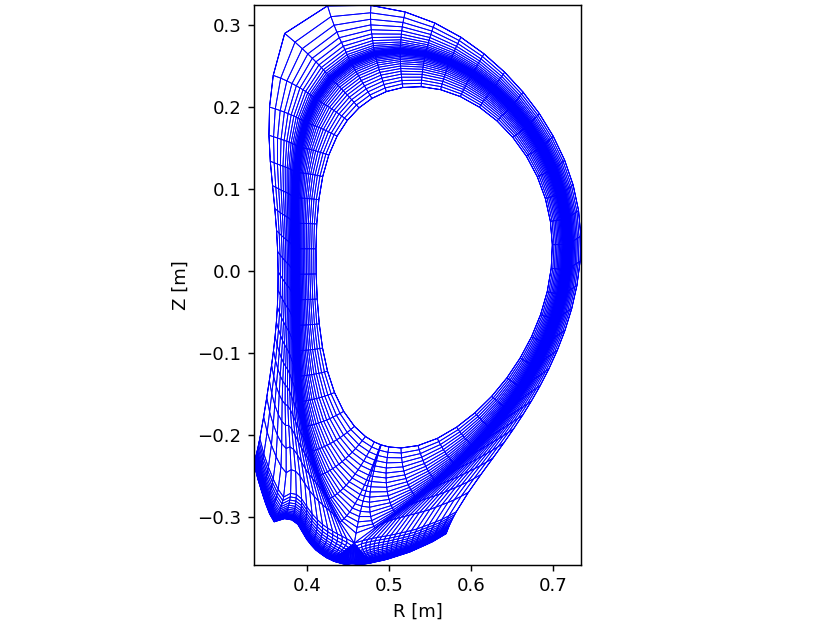

<Axes: xlabel='R [m]', ylabel='Z [m]'>

In [13]:
# Build a mesh object
mesh = SOLPSMesh.from_ds(dataset)

# Plot the mesh
mesh.plot()

While our mesh plotting abilities remain limited, you can refer to [SOLPS-doc: B2plot tutorial](https://solps.pages.tok.ipp.cas.cz/solps-doc/Processing_SOLPS-ITER_output/#b2plot).

### Plot the radial deuterium ion particle heat flux

Finally, we put together everything we've learned. We select the radiam deuterium ion particle flux and plot it using the `mesh` object.

<IPython.core.display.Javascript object>


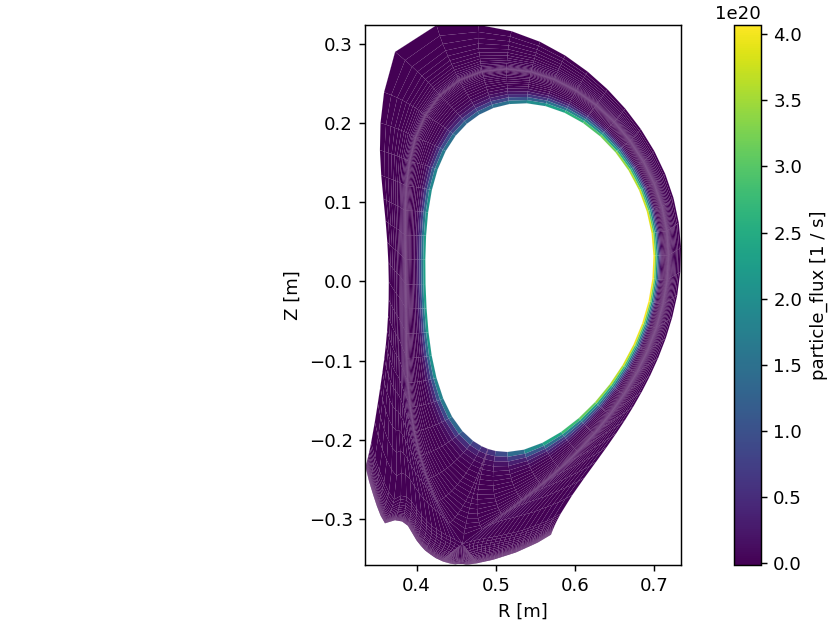

<Axes: xlabel='R [m]', ylabel='Z [m]'>

In [14]:
# Select the radial deuterium ion particle flux
Gammai_r = dataset.particle_flux.sel(species='D_1+', e_pol='radial')

# Plot the particle flux in 2D
mesh.plot(Gammai_r)

A static, bitmap version of this figure is shipped with this tutorial out-of-the-box. If you rerun the above notebook cell, however, you will get an interactive figure which you can zoom (using the rounded rectange button) or save to your computer (using the floppy disk button). To learn more about Python image manipulation, refer to any [beginner Matplotlib tutorial](https://www.w3schools.com/python/matplotlib_intro.asp).

## Loading data from your own SOLPS-ITER simulation

As listed above, the files needed by `solps-postproc` are `b2fstate`, `b2fplasmf`, `b2fgmtry`, `fort.44` and `b2mn.dat`. If your SOLPS-ITER simulation is on Soroban, just point `sim_path` to the run directory.

In [15]:
# Example of Soroban installation path to the run directory (not publicly available)
sim_path = '/net/soroban-node-06/scratch/jirakova/solps/solps-iter/runs/compass-16908-wall_300C/e3_i3'

If you run SOLPS-ITER somewhere else, like IT4I or the Marconi Gateway, you need to copy the files over to Soroban. Use any tool of choice, such as the `scp` command or file system mounting. Refer to [SOLPS-doc: Remote access](https://solps.pages.tok.ipp.cas.cz/solps-doc/Remote_access/) if you are lost.

- **b2fstate**: present in the `run` directory
- **fort.44**: present in the `run` directory if your run is coupled (B2.5+EIRENE, kinetic neutrals). If your run is standalone, `solps-postproc` can't load it. We're working on it.
- **b2mn.dat**: present in the `run` directory
- **b2fgmtry**: usually present in the `baserun` directory
- **b2fplasmf**: the only tricky file. While `b2fstate` and `fort.44` are automatically updated after each simulation run, `b2fplasmf` is not. Before you load a simulation using `solps-postproc`, you need to run the command

    ```
    b2run b2uf
    ```
    in the SOLPS work environment in the `run` directory. We recommend making a copy of `b2fstate` prior to using this command, as we've had bad experience with it deleting simulation results, overwriting `b2fstate` with the flat profiles solution. More on this in [SOLPS-doc: Common pitfalls](https://solps.pages.tok.ipp.cas.cz/solps-doc/Common_pitfalls/). A script for launching `b2run b2uf` safely is given in [SOLPS-doc: Cherab](https://solps.pages.tok.ipp.cas.cz/solps-doc/Processing_SOLPS-ITER_output/#providing-up-to-date-files-to-cherab).